In [ ]:
!pip install igraph
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import itertools
import operator
import networkx as nx

from scipy import stats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 119.5 MB/s eta 0:00:00


"\nfig, ax = plt.subplots()\nig.plot(\n    g,\n    target=ax,\n    layout='circle',\n    vertex_color='steelblue',\n    vertex_label=range(g.vcount()),\n    edge_width=1,\n    edge_color='#666',\n    edge_align_label=True,\n    edge_background='white'\n)\n"

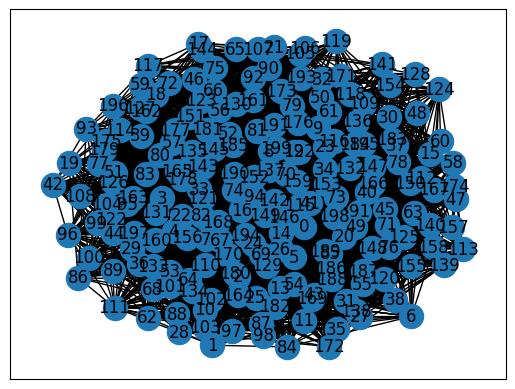

In [ ]:
from networkx.generators.random_graphs import erdos_renyi_graph
import networkx as nx

v = 200
p = 0.20
G = erdos_renyi_graph(v, p)
#G = nx.barabasi_albert_graph(100, 2)
E=[]
for i in G.edges:
  E.append(i)

allowedWeightValues = list(range(1,5))  #allowedWeightValues = [1, 2, 3, 4, 5]
noOfEdges = len(E)
g = ig.Graph(v, E)


nx.draw_networkx(G)
"""
fig, ax = plt.subplots()
ig.plot(
    g,
    target=ax,
    layout='circle',
    vertex_color='steelblue',
    vertex_label=range(g.vcount()),
    edge_width=1,
    edge_color='#666',
    edge_align_label=True,
    edge_background='white'
)
"""

In [ ]:
def findSEPR(path, WT):
  sEPR = max(WT)
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    if sEPR >= WT[index]:
      sEPR = WT[index]
  return sEPR
def updatePathWeight(path, pathWeight, updateFactor):
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    pathWeight[index] = pathWeight[index] - updateFactor
  return pathWeight

In [ ]:
def intersection(lst1, lst2):
    temp = set(lst2)
    lst3 = [value for value in lst1 if value in temp]
    return lst3

In [ ]:
AllPath = dict()
def getAllShortestPath(NodePairs):
  AllPath.clear()
  for (x,y) in NodePairs:
    if AllPath.get(x) == None:
      AllPath[x] = {}
    RX = [p for p in nx.all_simple_paths(G, x, y,2)]
    RX.sort(key=len)
    AllPath[x][y] = RX

In [ ]:
AllPathsEPR = dict()
def getAllsEPR(NodePairs, WT):
  AllPathsEPR.clear()
  for (x,y) in NodePairs:
    if AllPathsEPR.get(x) == None:
      AllPathsEPR[x] = {}
    if AllPathsEPR[x].get(y) == None:
      AllPathsEPR[x][y] = []
    for p in AllPath[x][y]:
      AllPathsEPR[x][y].append(findSEPR([p],WT))

In [ ]:
def getKthShortestPath(source, destination, k):
  RX = AllPath[source][destination]
  if k < len(RX):
    return [RX[k]], len(RX[k])-1
  else:
    return 0,0;
#shortestPath, shortestPathLength = getKthShortestPath(22,67,405)
#print(shortestPath, shortestPathLength)

In [ ]:
AllSortedsEPRs = dict()
AllSortedPathSEPR = dict()
def sortPathsBasedOnsEPRs(NodePairs):
  AllSortedsEPRs.clear()
  for (x,y) in NodePairs:
    S = sorted(zip(AllPathsEPR[x][y], AllSortedPathSEPR[x][y]), key = lambda x: (-x[0]))
    if AllSortedsEPRs.get(x) == None:
      AllSortedsEPRs[x] = {}
    if AllSortedsEPRs[x].get(y) == None:
      AllSortedsEPRs[x][y] = []
    AllSortedsEPRs[x][y], AllSortedPathSEPR[x][y] = [list(t) for t in zip(*S)]

In [ ]:
def HighsEPR(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  Kth = 0
  for i in range(len(RD)):
    for k in range(len(AllSortedPathSEPR[RDN[i][0]][RDN[i][1]])):
      t = RST[i]
      path = AllSortedPathSEPR[RDN[i][0]][RDN[i][1]][k]
      pathL = len(path) - 1
      if pathL > 0:
        if pathL == 1:
            TimeRemaining = RDT[i] - 1
        else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t< TimeRemaining and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight([path], WT[t], sEPR)
              if pathL == 1:
                t = t + 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight([path], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
  return EPRServed, SCHD, DServed

In [ ]:
def QoSScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  Kth = 0
  while sum(RD) > 0 and sum(RsPathL) > 0:
    S = sorted(zip(RD, RDT, RsPathL, RsPaths, RDN, RST), key = lambda x: (x[2], x[1], x[0]))
    RD,RDT,RsPathL,RsPaths,RDN, RPI = [list(t) for t in zip(*S)]
    for i in range(len(RD)):
      t = RST[i]
      pathL = RsPathL[i]
      if pathL > 0:
        #print(RsPaths[i])
        if pathL == 1:
            TimeRemaining = RDT[i] - 1
        else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t< TimeRemaining and RD[i]>0:
          sEPR = findSEPR(RsPaths[i], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight(RsPaths[i], WT[t], sEPR)
              if pathL == 1:
                t = t + 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight(RsPaths[i], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
    Kth+=1
    RsPaths = list()
    RsPathL = list()
    for k in RDN:
      shortestPath, shortestPathLength = getKthShortestPath(k[0], k[1], Kth)
      RsPaths.append(shortestPath)
      RsPathL.append(shortestPathLength)
  return EPRServed, SCHD, DServed

In [ ]:
# Uses all_shortest_paths -> updated to all_simple_paths
def PIScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RPI, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      if pathL < math.pow(2, RDT[i]) and RD[i]>0:
        t = RST[i]
        if pathL == 1:
          TimeRemaining = RDT[i] - 1
        else:
          TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t<TimeRemaining and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              runningTime = math.ceil(math.log2(pathL))
              tempT = t
              while tempT < t+runningTime:
                WT[tempT] = updatePathWeight([path], WT[tempT], sEPR)
                tempT += 1
              if pathL == 1:
                t += 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              runningTime = math.ceil(math.log2(pathL))
              tempT = t
              while tempT < t+runningTime:
                WT[tempT] = updatePathWeight([path], WT[tempT], RD[i])
                tempT += 1
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
  return EPRServed, SCHD, DServed

In [ ]:
# Uses all_simple_paths
def splitScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    #print(RX)
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      #print(path)
      if pathL < math.pow(2, RDT[i]-RST[i]) and RD[i]>0:
        t = RST[i]
        while t<(RDT[i]-math.ceil(math.log(pathL))) and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight([path], WT[t], sEPR)
              t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight([path], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
  return EPRServed, SCHD, DServed

In [ ]:
def naive(SN):
  #Find the shortest path for the demand
  #Try to reserve resources on the shortest path
  #If not possible, loop over n such paths without splitting and try to reserve resources
  #If no path is available, mark it failed
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    # print('shortest path')
    # RX = [p for p in nx.all_shortest_paths(G, RDN[i][0], RDN[i][1])]
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    path_counter = 0
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      breakFlag = False
      if pathL < math.pow(2, RDT[i]-RST[i]):
        path_counter += 1
        t = RST[i]
        while t<(RDT[i]-math.ceil(math.log(pathL))):
          sEPR = findSEPR([path], WT[t])
          # print(f'Debugging Naive:------ For Demand: {( RDN[i][0], RDN[i][1])} Path: {path} and time: {t} Req EPR: {RD[i]} and sEPR: {sEPR}')
          if RD[i]<sEPR:
            EPRServed += RD[i]
            WT[t] = updatePathWeight([path], WT[t], RD[i])
            SCHD[t].append((RDN[i],RD[i]))
            RD[i] = 0
            DServed += 1
            breakFlag=True
            break
          else:
            t += 1
        if breakFlag:
          break
    #print(f'Naive:------ Demand: {( RDN[i][0], RDN[i][1])} and available no. of paths: {len(RX)}, unuseful no. of paths: {len(RX)-path_counter}')
  #print(f'EPRServed: {EPRServed}, DServed: {DServed}')
  return EPRServed, SCHD, DServed

**vDensity**

In [ ]:
def path_and_time_intersection(p1, p2, st1, et1, st2, et2):
  # print(st1, et1, st2, et2)
  #If there is no temporal overlap, there is no point in checking overlapping paths
  if (et1<=st2) or (et2<=st1):
    return []
  temp = set(p2)
  lst3 = [value for value in p1 if value in temp]
  # print(lst3)
  return lst3

In [ ]:
lowerBound = 0.2
upperBound = 1.01
step = 0.1
densities = np.arange(lowerBound, upperBound, step)
num_densities = len(densities)
num_trials = 50
v = 50

# MODIFIED: Store raw results in 2D arrays (num_trials x num_densities) for CI computation
all_dres1 = np.zeros((num_trials, num_densities))
all_dres2 = np.zeros((num_trials, num_densities))
all_dres3 = np.zeros((num_trials, num_densities))
all_dres4 = np.zeros((num_trials, num_densities))
all_dres5 = np.zeros((num_trials, num_densities))

for trial in range(num_trials):
  print('trial:', trial)
  k = 500
  allowedWeightValues = list(range(1,5))

  for d_idx, density_val in enumerate(densities):
    print('density:', density_val)
    G = erdos_renyi_graph(v, density_val)
    E=[]
    for j in G.edges:
      E.append(j)
    noOfEdges = len(E)
    g = ig.Graph(v, E)
    W = random.choices(allowedWeightValues, k=noOfEdges)
    CP = random.sample(list((x,y) for x,y in itertools.product(range(v), repeat = 2) if x!=y and x<y), k=k)
    DN=[]
    for i in CP:
      RX = [p for p in nx.all_simple_paths(G, i[0], i[1],2)]
      if len(RX) != 0:
        DN.append(i)
    noOfDemands = len(DN)
    D = random.choices(list(range(1,20)), k=noOfDemands)
    DT = random.choices(list(range(5,10)), k=noOfDemands)
    DST = random.choices(list(range(0,5)), k=noOfDemands)
    getAllShortestPath(DN)
    getAllsEPR(DN, W)
    AllSortedPathSEPR = AllPath.copy()
    sortPathsBasedOnsEPRs(DN)
    sPaths = list()
    sPathL = []
    for j in DN:
      shortestPath = g.get_shortest_paths(j[0], to=j[1], output="vpath")
      sPaths.append(shortestPath)
      sPathL.append(len(shortestPath[0])-1)

    ST  = [0 for a in range(len(D))]
    m = 0
    Paths = sPaths
    P = [0 for i in range(len(Paths))]
    for l in Paths:
      P[m] = []
      for q in l:
        for i in range(len(q)-1):
          P[m].append((q[i], q[i+1]))
      m += 1
    m = 0
    PI = [0 for i in range(len(P))]
    for i in P:
      for j in P:
        if intersection(i, j):
          PI[m] += 1
        else:
          j_r = [(y,x) for (x,y) in j]
          if intersection(i, j_r):
            PI[m] += 1
      m += 1
    NS = [a for a in zip(D, DT, sPathL, sPaths, DN, DST)]
    S = sorted(zip(D, DT, sPathL, sPaths, DN, DST), key = lambda x: (x[1], x[0], x[2]))
    PI_S = sorted(zip(D, DT, sPathL, sPaths, DN, PI, DST), key = lambda x: (x[5], x[2], x[0], x[1]))

    eprserved1, schd1, dserved1 = splitScheduling(S)
    eprserved4, schd4, dserved4 = PIScheduling(PI_S)
    eprserved2, schd2, dserved2 = naive(NS)
    eprserved3, schd3, dserved3 = QoSScheduling(NS)
    eprserved5, schd5, dserved5 = HighsEPR(S)

    # MODIFIED: Record trial fractions directly into 2D matrices
    all_dres1[trial, d_idx] = dserved1 / len(D)
    all_dres2[trial, d_idx] = dserved2 / len(D)
    all_dres3[trial, d_idx] = dserved3 / len(D)
    all_dres4[trial, d_idx] = dserved4 / len(D)
    all_dres5[trial, d_idx] = dserved5 / len(D)

trial: 0
density: 0.2
density: 0.30000000000000004
density: 0.4000000000000001
density: 0.5000000000000001
density: 0.6000000000000001
density: 0.7000000000000002
density: 0.8000000000000003
density: 0.9000000000000001
density: 1.0000000000000002
trial: 1
density: 0.2
density: 0.30000000000000004
density: 0.4000000000000001
density: 0.5000000000000001
density: 0.6000000000000001
density: 0.7000000000000002
density: 0.8000000000000003
density: 0.9000000000000001
density: 1.0000000000000002
trial: 2
density: 0.2
density: 0.30000000000000004
density: 0.4000000000000001
density: 0.5000000000000001
density: 0.6000000000000001
density: 0.7000000000000002
density: 0.8000000000000003
density: 0.9000000000000001
density: 1.0000000000000002
trial: 3
density: 0.2
density: 0.30000000000000004
density: 0.4000000000000001
density: 0.5000000000000001
density: 0.6000000000000001
density: 0.7000000000000002
density: 0.8000000000000003
density: 0.9000000000000001
density: 1.0000000000000002
trial: 4
den

In [ ]:
def compute_mean_and_ci(data_matrix, confidence=0.95):
    means = np.mean(data_matrix, axis=0)
    sem = stats.sem(data_matrix, axis=0)
    # Student's t multiplier for N-1 degrees of freedom
    h = sem * stats.t.ppf((1 + confidence) / 2., num_trials - 1)
    return means, h

In [ ]:
mean_dres1, ci_dres1 = compute_mean_and_ci(all_dres1)
mean_dres2, ci_dres2 = compute_mean_and_ci(all_dres2)
mean_dres3, ci_dres3 = compute_mean_and_ci(all_dres3)
mean_dres4, ci_dres4 = compute_mean_and_ci(all_dres4)
mean_dres5, ci_dres5 = compute_mean_and_ci(all_dres5)

In [ ]:
import numpy as np

np.savez('CI_Density.npz',
         x_axis=densities,
         mean_dres1=mean_dres1, ci_dres1=ci_dres1,
         mean_dres2=mean_dres2, ci_dres2=ci_dres2,
         mean_dres3=mean_dres3, ci_dres3=ci_dres3,
         mean_dres4=mean_dres4, ci_dres4=ci_dres4,
         mean_dres5=mean_dres5, ci_dres5=ci_dres5)
print("Data saved successfully to simulation_results.npz")

Data saved successfully to simulation_results.npz


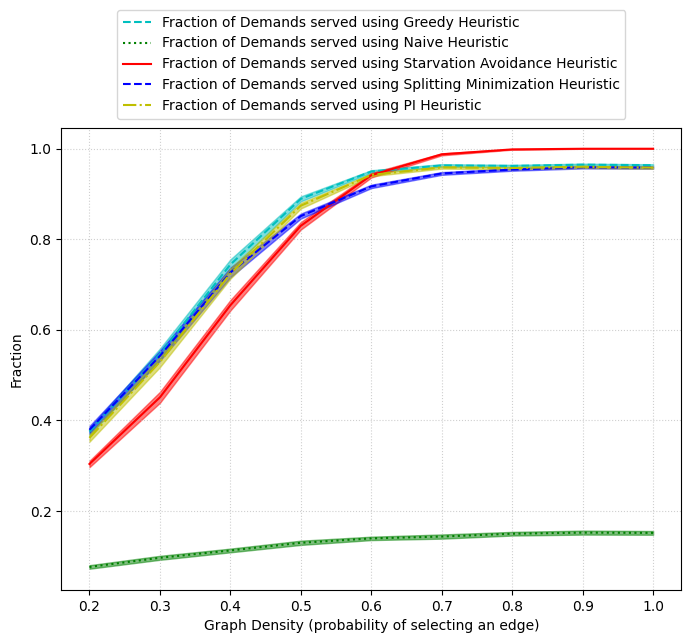

In [ ]:
plt.figure(figsize=(8, 6))

# Define series parameters
series_config = [
    (mean_dres1, ci_dres1, 'c', 'dashed', 'Fraction of Demands served using Greedy Heuristic'),
    (mean_dres2, ci_dres2, 'g', 'dotted', 'Fraction of Demands served using Naive Heuristic'),
    (mean_dres3, ci_dres3, 'r', 'solid', 'Fraction of Demands served using Starvation Avoidance Heuristic'),
    (mean_dres4, ci_dres4, 'b', 'dashed', 'Fraction of Demands served using Splitting Minimization Heuristic'),
    (mean_dres5, ci_dres5, 'y', 'dashdot', 'Fraction of Demands served using PI Heuristic'),
]

for mean_val, ci_val, color, style, label in series_config:
    plt.plot(densities, mean_val, color=color, label=label, linestyle=style)
    # ADDED: Render semi-transparent 95% CI bands
    plt.fill_between(densities, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.5)

plt.xlabel("Graph Density (probability of selecting an edge)")
plt.ylabel("Fraction")
plt.legend(bbox_to_anchor=(0.5, 1.27), loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('vsGraphDensity_with_CI.png', bbox_inches='tight', dpi=500)
plt.show()

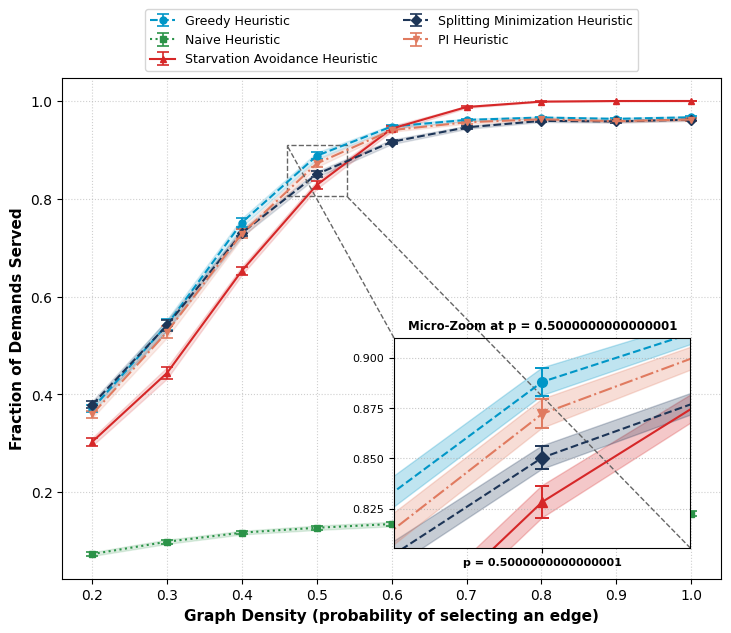

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.5, 6.5))

series_config = [
    (mean_dres1, ci_dres1, '#0096c7', '--', 'o', 'Greedy Heuristic'),
    (mean_dres2, ci_dres2, '#2b9348', ':', 's', 'Naive Heuristic'),
    (mean_dres3, ci_dres3, '#d62728', '-', '^', 'Starvation Avoidance Heuristic'),
    (mean_dres4, ci_dres4, '#1d3557', '--', 'D', 'Splitting Minimization Heuristic'),
    (mean_dres5, ci_dres5, '#e07a5f', '-.', 'v', 'PI Heuristic'),
]

# --- Main Plot ---
for mean_val, ci_val, color, style, marker, label in series_config:
    ax.errorbar(
        densities, mean_val, yerr=ci_val, color=color, linestyle=style,
        marker=marker, markersize=5, capsize=4, capthick=1.2, elinewidth=1.2,
        label=f'{label}'
    )
    ax.fill_between(densities, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.15)

ax.set_xlabel("Graph Density (probability of selecting an edge)", fontsize=11, fontweight='bold')
ax.set_ylabel("Fraction of Demands Served", fontsize=11, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=2, fontsize=9, frameon=True)

# --- Dynamic Index Finding for Exact p = 0.5 ---
target_p = 0.5
densities_arr = np.array(densities)
target_idx = int(np.argmin(np.abs(densities_arr - target_p)))  # Finds closest index matching 0.5
target_x = densities[target_idx]

# --- Micro-Zoom Inset Box ---
axins = inset_axes(ax, width="45%", height="42%", loc="lower right", borderpad=2.2)

# Exclude Naive baseline from inset to maximize vertical zoom
for mean_val, ci_val, color, style, marker, label in series_config:
    if 'Naive' in label:
        continue
    axins.errorbar(
        densities, mean_val, yerr=ci_val, color=color, linestyle=style,
        marker=marker, markersize=7, capsize=5, capthick=1.4, elinewidth=1.4
    )
    axins.fill_between(densities, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.25)

# --- TIGHT BOUNDS STRICTLY AROUND p = 0.5 ---
axins.set_xlim(target_x - 0.04, target_x + 0.04)

# Calculate dynamic vertical limits for top heuristics at target_idx (p = 0.5)
top_y = [m[target_idx] for m, _, _, _, _, label in series_config if 'Naive' not in label]
top_ci = [c[target_idx] for _, c, _, _, _, label in series_config if 'Naive' not in label]

y_min = min(y - ci for y, ci in zip(top_y, top_ci))
y_max = max(y + ci for y, ci in zip(top_y, top_ci))
padding = (y_max - y_min) * 0.20 if (y_max - y_min) > 0 else 0.01

axins.set_ylim(y_min - padding, y_max + padding)

# --- Inset Axis Formatting ---
axins.set_xticks([target_x])
axins.set_xticklabels([f'p = {target_x}'], fontsize=8.5, fontweight='bold')
axins.yaxis.set_major_locator(MaxNLocator(5))
axins.tick_params(axis='both', labelsize=8)
axins.grid(True, linestyle=':', alpha=0.7)
axins.set_title(f"Micro-Zoom at p = {target_x}", fontsize=8.5, fontweight='bold')

# Connect inset box cleanly to main plot
_ = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", ls="--")

plt.savefig('vsGraphDensity_Zoom_p05.png', bbox_inches='tight', dpi=500)
plt.show()